# Notebook 03 — Exploratory Data Analysis

## Objectives
- Examine the distribution of the Churn target variable
- Identify numeric features most correlated with Churn via heatmap
- Visualise key categorical and numeric features against Churn
- Save all plots to `outputs/eda/` for display in the Streamlit dashboard
- Answer Business Requirement 1

## Inputs
- `outputs/datasets/collection/telco_churn_cleaned.csv`

## Outputs
- `outputs/eda/churn_distribution.png`
- `outputs/eda/correlation_heatmap.png`
- `outputs/eda/tenure_vs_churn.png`
- `outputs/eda/monthlycharges_vs_churn.png`
- `outputs/eda/contract_vs_churn.png`
- `outputs/eda/techsupport_vs_churn.png`
- `outputs/eda/internetservice_vs_churn.png`

---

## 1. Change Working Directory

In [1]:
import os

os.chdir('..') if os.path.basename(os.getcwd()) == 'jupyter_notebooks' else None
os.makedirs('outputs/eda', exist_ok=True)
print('Working directory:', os.getcwd())

Working directory: /workspaces/customer-churn-predictor


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

## 3. Load Cleaned Dataset

In [3]:
df = pd.read_csv('outputs/datasets/collection/telco_churn_cleaned.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## 4. Churn Distribution

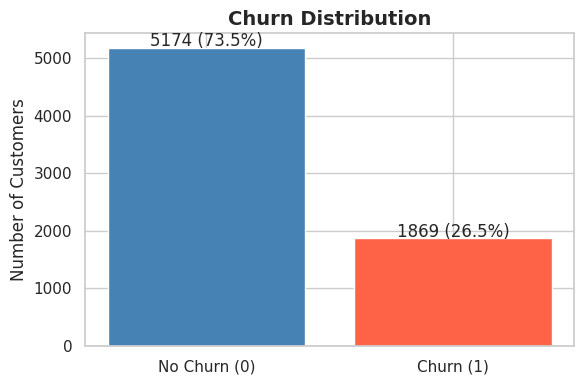

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Churn'].value_counts()
ax.bar(['No Churn (0)', 'Churn (1)'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
# Annotate bars with count and percentage
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('outputs/eda/churn_distribution.png', dpi=150)
plt.show()

**Finding:** ~26.5% of customers churned. The class imbalance will be addressed with SMOTE oversampling during modelling.

## 5. Correlation Heatmap

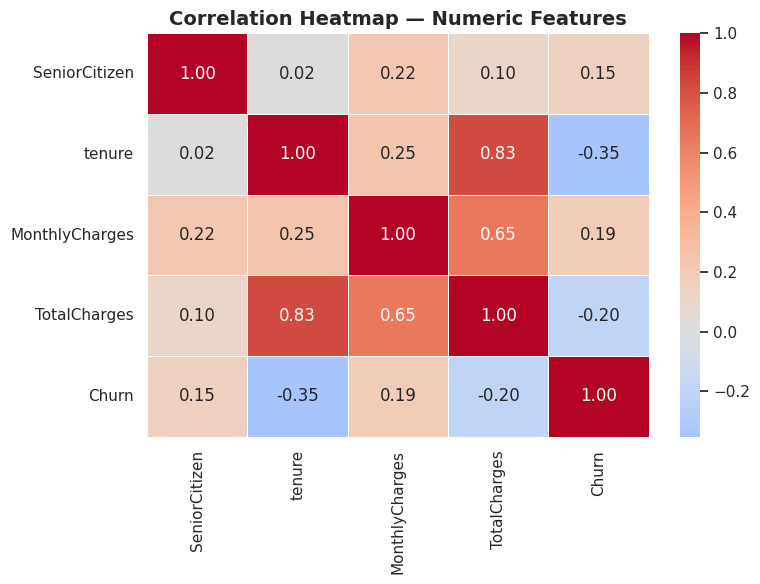


Correlation with Churn:
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199037
tenure           -0.352229
Name: Churn, dtype: float64


In [5]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda/correlation_heatmap.png', dpi=150)
plt.show()

# Print correlation values with Churn, sorted descending
print('\nCorrelation with Churn:')
print(corr_matrix['Churn'].drop('Churn').sort_values(ascending=False))

**Finding:** `tenure` has the strongest negative correlation (-0.35) — longer-tenured customers are less likely to churn. `MonthlyCharges` has a positive correlation (+0.19).

## 6. Tenure vs Churn

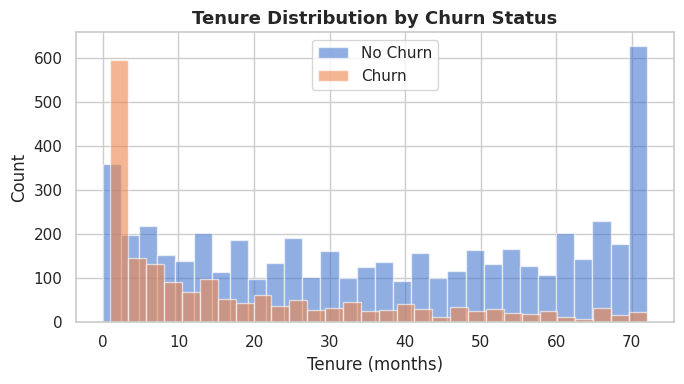

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in df.groupby('Churn'):
    grp['tenure'].plot(kind='hist', alpha=0.6, bins=30, ax=ax,
                       label='Churn' if label == 1 else 'No Churn')
ax.set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/eda/tenure_vs_churn.png', dpi=150)
plt.show()

**Finding:** Churned customers are heavily concentrated at low tenure. New customers are the most at-risk group.

## 7. Monthly Charges vs Churn

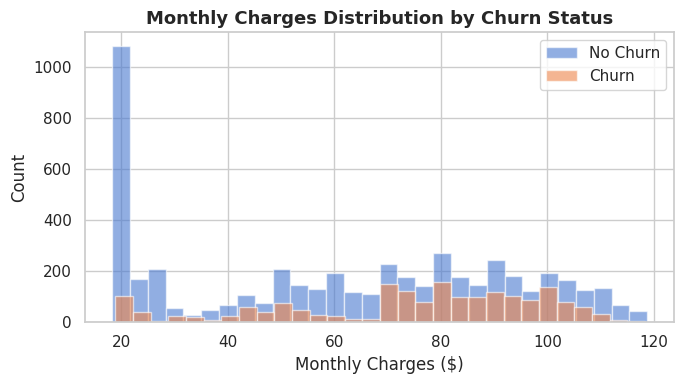

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in df.groupby('Churn'):
    grp['MonthlyCharges'].plot(kind='hist', alpha=0.6, bins=30, ax=ax,
                               label='Churn' if label == 1 else 'No Churn')
ax.set_title('Monthly Charges Distribution by Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/eda/monthlycharges_vs_churn.png', dpi=150)
plt.show()

**Finding:** Churned customers tend to have higher monthly charges, suggesting price sensitivity is a driver of churn.

## 8. Contract Type vs Churn

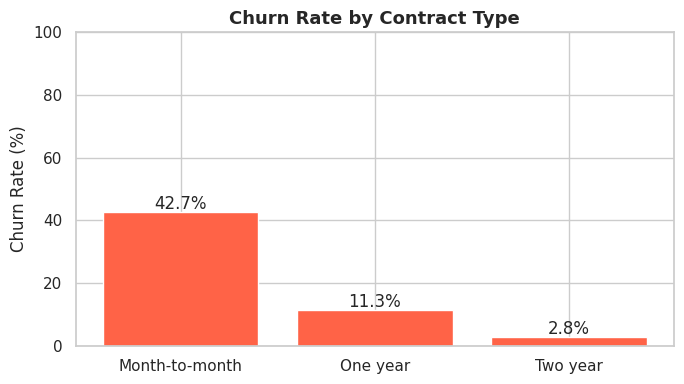

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
ax.bar(contract_churn.index, contract_churn.values * 100, color='tomato')
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
for i, v in enumerate(contract_churn.values):
    ax.text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('outputs/eda/contract_vs_churn.png', dpi=150)
plt.show()

**Finding:** Month-to-month customers churn at ~43% vs ~3% for two-year contracts. Long-term contracts are the strongest retention mechanism in the data.

## 9. Tech Support vs Churn

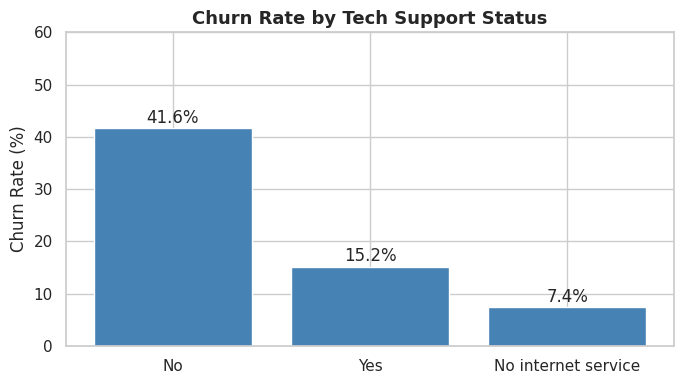

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ts_churn = df.groupby('TechSupport')['Churn'].mean().sort_values(ascending=False)
ax.bar(ts_churn.index, ts_churn.values * 100, color='steelblue')
ax.set_title('Churn Rate by Tech Support Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(ts_churn.values):
    ax.text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('outputs/eda/techsupport_vs_churn.png', dpi=150)
plt.show()

**Finding:** Customers without tech support churn at roughly twice the rate of those who have it.

## 10. Internet Service vs Churn

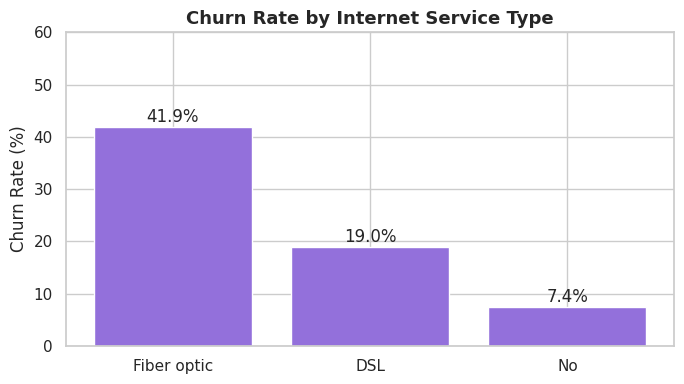

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
is_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
ax.bar(is_churn.index, is_churn.values * 100, color='mediumpurple')
ax.set_title('Churn Rate by Internet Service Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(is_churn.values):
    ax.text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('outputs/eda/internetservice_vs_churn.png', dpi=150)
plt.show()

**Finding:** Fibre optic customers churn at ~42% vs ~19% for DSL. This may reflect higher price expectations for the premium tier.

---
## Conclusions
- **Business Requirement 1 answered:** The strongest predictors of churn are `tenure`, `MonthlyCharges`, `Contract` type, `TechSupport`, and `InternetService`.
- Class imbalance (~26.5% churn) confirmed — SMOTE will be applied during modelling.
- All plots saved to `outputs/eda/`.